In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Literal, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.features import shapes
from shapely.geometry import shape
import geopandas as gpd
from scipy.ndimage import label as cc_label
from pyproj import Transformer


@dataclass(frozen=True)
class PatchCentroid:
    """
    A trend patch represented by its centroid.

    Attributes
    ----------
    patch_id : int
        Connected-component label id.
    mean_z : float
        Mean Mann–Kendall z-score within the patch.
    x, y : float
        Centroid coordinates in the native CRS of trend_z raster (e.g., MODIS Sinusoidal meters).
        Used for sampling after reprojection to annual stack CRS.
    lon, lat : float
        Centroid coordinates in WGS84 (EPSG:4326), used for legend labels.
    """
    patch_id: int
    mean_z: float
    x: float
    y: float
    lon: float
    lat: float


def plot_topk_trend_patch_centroid_timeseries(
    annual_stack_tif: str | Path,
    trend_z_tif: str | Path,
    years: Sequence[int],
    *,
    mode: Literal["degrading", "improving"] = "degrading",
    topk: int = 25,
    z_threshold: float | None = None,
    connectivity: int = 8,
    figsize: tuple[float, float] = (12, 7),
    linestyle: str = "--",
    linewidth: float = 1.5,
    legend_decimals: int = 4,
    legend_fontsize: int = 9,
    grid_alpha: float = 0.3,
    title: str | None = None,
) -> tuple[pd.DataFrame, plt.Figure, plt.Axes, list[PatchCentroid]]:
    """
    Plot time series of annual productivity values sampled at centroids of the top-K
    most degrading or most improving land patches according to a Trend Z-score raster.

    Parameters
    ----------
    annual_stack_tif
        Multi-band GeoTIFF of annual productivity values. Band order must match `years`.
    trend_z_tif
        Single-band GeoTIFF of Mann–Kendall Z-scores (Trend significance & direction).
    years
        Years aligned to annual stack bands, e.g. list(range(2000, 2016)).
    mode
        - "degrading": select patches where z < negative threshold; rank by mean_z ascending.
        - "improving": select patches where z > positive threshold; rank by mean_z descending.
    topk
        Number of patches to plot (default 25).
    z_threshold
        Z-score threshold for selecting pixels.
        If None:
          - degrading uses -1.96
          - improving uses +1.96
    connectivity
        4 or 8 neighborhood for connected components (default 8).
    figsize, linestyle, linewidth, legend_decimals, legend_fontsize, grid_alpha
        Matplotlib styling.
    title
        Optional explicit plot title. If None, a default title is used.

    Returns
    -------
    df : pandas.DataFrame
        Columns: id, year, lon, lat, prod
        lon/lat are WGS84 for readability and legend.
    fig, ax : matplotlib Figure/Axes
    selected_patches : list[PatchCentroid]
        Metadata of the selected patches.

    Notes
    -----
    - Robust to CRS differences. Works when both rasters are MODIS Sinusoidal.
    - If all sampled `prod` values become NaN, it usually means CRS metadata is wrong
      or the selected centroid points fall outside the annual stack extent.
    """
    annual_stack_tif = Path(annual_stack_tif)
    trend_z_tif = Path(trend_z_tif)
    years = list(years)

    if not years:
        raise ValueError("`years` must be non-empty and aligned to stack band order.")
    if connectivity not in (4, 8):
        raise ValueError("`connectivity` must be 4 or 8.")
    if mode not in ("degrading", "improving"):
        raise ValueError("`mode` must be 'degrading' or 'improving'.")

    if z_threshold is None:
        z_threshold = -1.96 if mode == "degrading" else 1.96
    z_threshold = float(z_threshold)

    # -------------------------
    # 1) Read Z-score raster & build mask
    # -------------------------
    with rasterio.open(trend_z_tif) as zsrc:
        z = zsrc.read(1).astype(np.float32)
        z_crs = zsrc.crs
        z_transform = zsrc.transform
        z_nodata = zsrc.nodata

        if z_crs is None:
            raise ValueError("trend_z raster has no CRS. Please fix CRS metadata first.")
        if z_nodata is not None:
            z[z == z_nodata] = np.nan

        if mode == "degrading":
            mask_sel = np.isfinite(z) & (z < z_threshold)
        else:  # improving
            mask_sel = np.isfinite(z) & (z > z_threshold)

        structure = (
            np.array([[0, 1, 0],
                      [1, 1, 1],
                      [0, 1, 0]], dtype=np.uint8)
            if connectivity == 4
            else np.ones((3, 3), dtype=np.uint8)
        )
        labels, nlab = cc_label(mask_sel.astype(np.uint8), structure=structure)

    if nlab == 0:
        fig, ax = plt.subplots(figsize=figsize)
        ax.set_xlabel("Year")
        ax.set_ylabel("Annual Productivity")
        ax.set_title(f"No {mode} patches found (check threshold / inputs).")
        return (
            pd.DataFrame(columns=["id", "year", "lon", "lat", "prod"]),
            fig,
            ax,
            [],
        )

    # Transformer: z_crs -> WGS84 for legend
    to_wgs84 = Transformer.from_crs(z_crs, "EPSG:4326", always_xy=True)

    # -------------------------
    # 2) Convert labeled patches to polygons -> centroid -> patch stats
    # -------------------------
    patches: list[PatchCentroid] = []

    for geom, val in shapes(labels.astype(np.int32), mask=mask_sel, transform=z_transform):
        patch_id = int(val)
        if patch_id == 0:
            continue

        poly = shape(geom)
        pix_mask = (labels == patch_id)
        mean_z = float(np.nanmean(z[pix_mask]))

        c_native = poly.centroid
        x, y = float(c_native.x), float(c_native.y)

        lon, lat = to_wgs84.transform(x, y)

        patches.append(PatchCentroid(patch_id=patch_id, mean_z=mean_z, x=x, y=y, lon=float(lon), lat=float(lat)))

    # Rank & select
    if mode == "degrading":
        patches.sort(key=lambda p: p.mean_z)           # most negative first
    else:
        patches.sort(key=lambda p: p.mean_z, reverse=True)  # most positive first

    selected = patches[: int(topk)]

    # -------------------------
    # 3) Sample annual stack at centroid points
    # -------------------------
    rows: list[dict[str, float | int]] = []

    with rasterio.open(annual_stack_tif) as asrc:
        if asrc.count != len(years):
            raise ValueError(
                f"Band count mismatch: annual stack has {asrc.count} bands, but `years` has {len(years)} entries."
            )

        # Build points in z_crs using native x/y -> reproject to annual stack CRS for sampling
        gdf_pts = gpd.GeoDataFrame(
            {"id": list(range(len(selected)))},
            geometry=gpd.points_from_xy([p.x for p in selected], [p.y for p in selected]),
            crs=z_crs,
        ).to_crs(asrc.crs)

        coords = [(geom.x, geom.y) for geom in gdf_pts.geometry]

        for i, vals in enumerate(asrc.sample(coords)):
            for b, year in enumerate(years):
                rows.append(
                    {
                        "id": i,
                        "year": int(year),
                        "lon": float(selected[i].lon),  # WGS84 for legend/df
                        "lat": float(selected[i].lat),
                        "prod": float(vals[b]),
                    }
                )

    df = pd.DataFrame(rows).sort_values(["id", "year"]).reset_index(drop=True)

    finite_ratio = np.isfinite(df["prod"].to_numpy()).mean()
    if finite_ratio == 0.0:
        raise RuntimeError(
            "All sampled productivity values are NaN. "
            "This usually means centroid points are outside the annual stack extent, "
            "or CRS metadata is incorrect."
        )

    # -------------------------
    # 4) Filter patches with complete time series (no missing years)
    # -------------------------
    # 检查每个patch是否所有年份都有有效值
    complete_ids = []
    for pid, g in df.groupby("id", sort=True):
        prod_values = g["prod"].to_numpy()
        if np.all(np.isfinite(prod_values)):  # 所有年份都有有效值
            complete_ids.append(pid)
    
    if not complete_ids:
        fig, ax = plt.subplots(figsize=figsize)
        ax.set_xlabel("Year")
        ax.set_ylabel("Annual Productivity")
        ax.set_title(f"No patches with complete time series found (all have missing years).")
        return (
            pd.DataFrame(columns=["id", "year", "lon", "lat", "prod"]),
            fig,
            ax,
            [],
        )
    
    # 只保留时间序列完整的patch
    df_complete = df[df["id"].isin(complete_ids)].copy()
    selected_complete = [selected[i] for i in complete_ids]
    
    # 重新映射id使其连续（0, 1, 2, ...）
    id_mapping = {old_id: new_id for new_id, old_id in enumerate(complete_ids)}
    df_complete["id"] = df_complete["id"].map(id_mapping)
    
    print(f"Filtered: {len(selected)} patches -> {len(complete_ids)} patches with complete time series")

    # -------------------------
    # 5) Plot (保持原有样式)
    # -------------------------
    fig, ax = plt.subplots(figsize=figsize)

    for pid, g in df_complete.groupby("id", sort=True):
        lon = float(g["lon"].iloc[0])
        lat = float(g["lat"].iloc[0])
        ax.plot(
            g["year"].to_numpy(),
            g["prod"].to_numpy(),
            linestyle=linestyle,
            linewidth=linewidth,
            label=f"{lon:.{legend_decimals}f},{lat:.{legend_decimals}f}",
        )

    ax.set_xlabel("Year")
    ax.set_ylabel("Annual Productivity")
    ax.grid(True, alpha=grid_alpha)

    if title is None:
        sign = "<" if mode == "degrading" else ">"
        title = f"Top {len(complete_ids)} {mode} patches (z {sign} {z_threshold:+.2f}) centroid time series"
    ax.set_title(title)

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True,
        fontsize=legend_fontsize,
    )
    plt.tight_layout()


    return df_complete, fig, ax, selected_complete


Filtered: 25 patches -> 25 patches with complete time series
Filtered: 25 patches -> 25 patches with complete time series


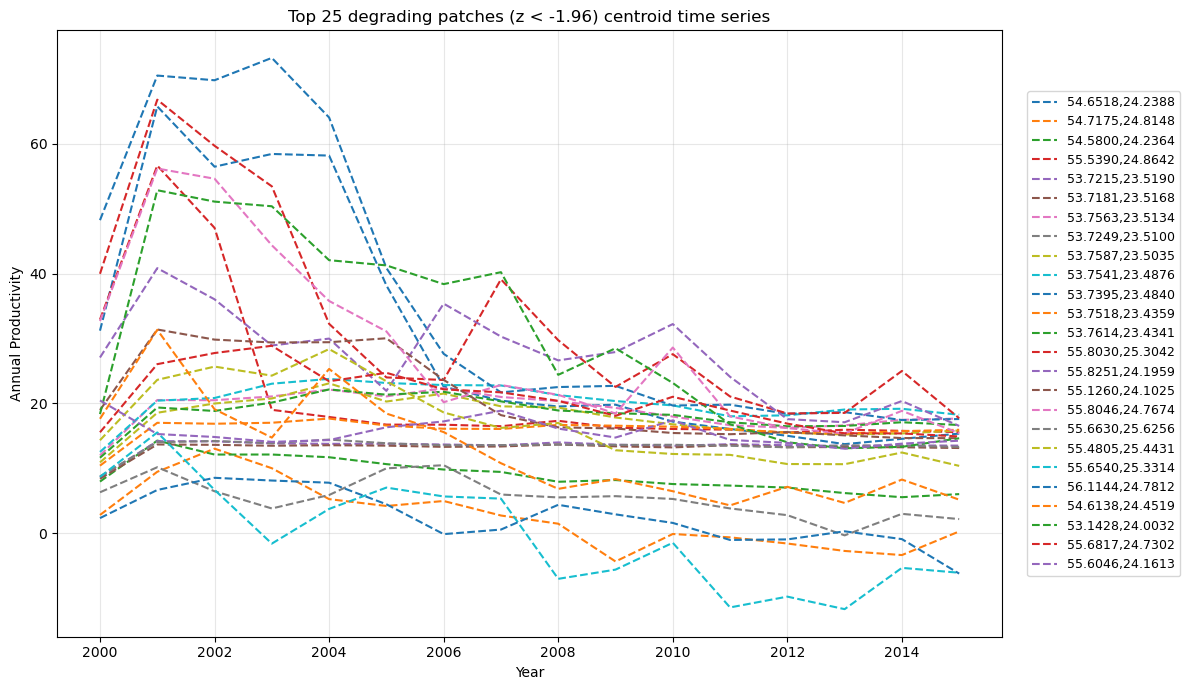

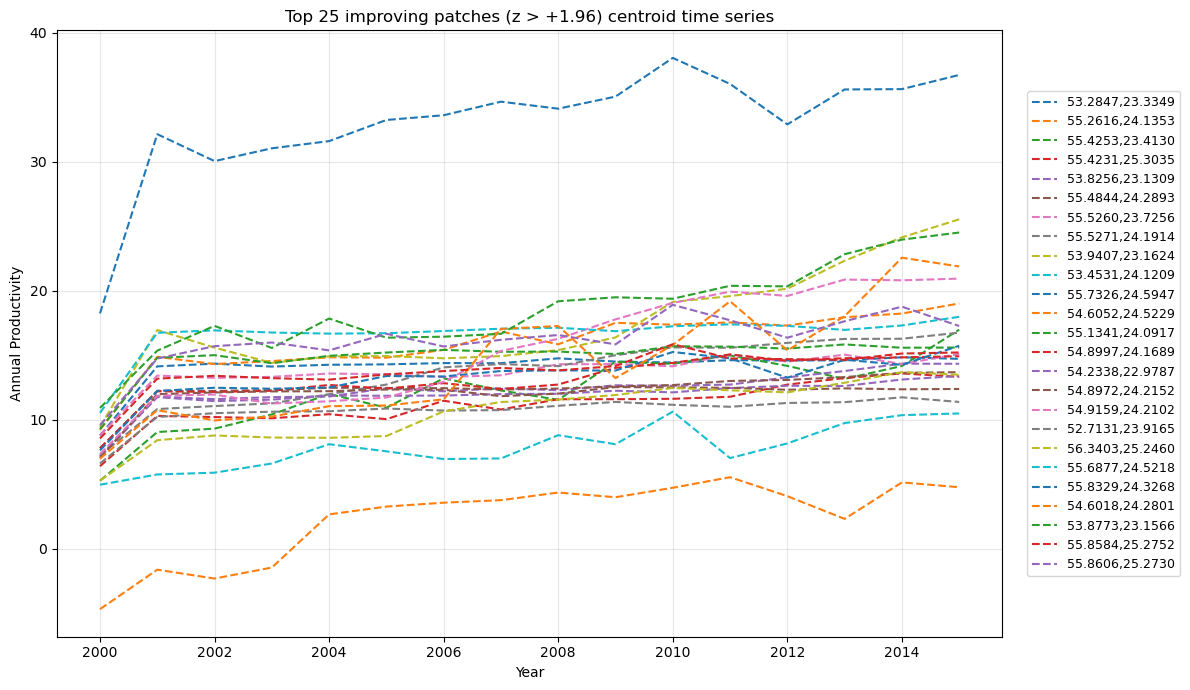

In [2]:
years = list(range(2000, 2016))

# Figure 12: degrading（z < -1.96）
df_deg, fig_deg, ax_deg, patches_deg = plot_topk_trend_patch_centroid_timeseries(
    annual_stack_tif="../data/NPP_PROXY/annual_auc_toBands_2000_2015.tif",
    trend_z_tif="../output/trend/2015/zscore.tif",
    years=years,
    mode="degrading",
    topk=25,
    z_threshold=-1.96,
)

# Figure 13: improving（z > +1.96）
df_imp, fig_imp, ax_imp, patches_imp = plot_topk_trend_patch_centroid_timeseries(
    annual_stack_tif="../data/NPP_PROXY/annual_auc_toBands_2000_2015.tif",
    trend_z_tif="../output/trend/2015/zscore.tif",
    years=years,
    mode="improving",
    topk=25,
    z_threshold=1.96,
)



In [4]:
fig_deg.savefig("../output/trend/2015/degrading_pic.png")

fig_imp.savefig("../output/trend/2015/improving_pic.png")


Filtered: 25 patches -> 25 patches with complete time series
Filtered: 25 patches -> 25 patches with complete time series


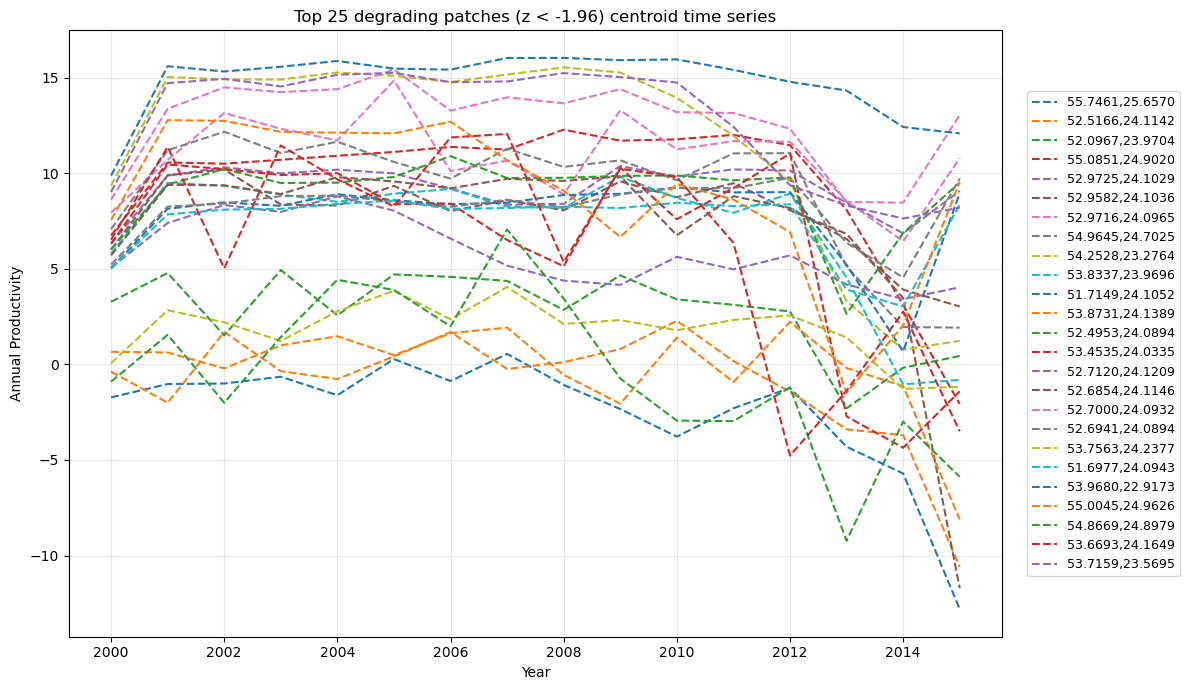

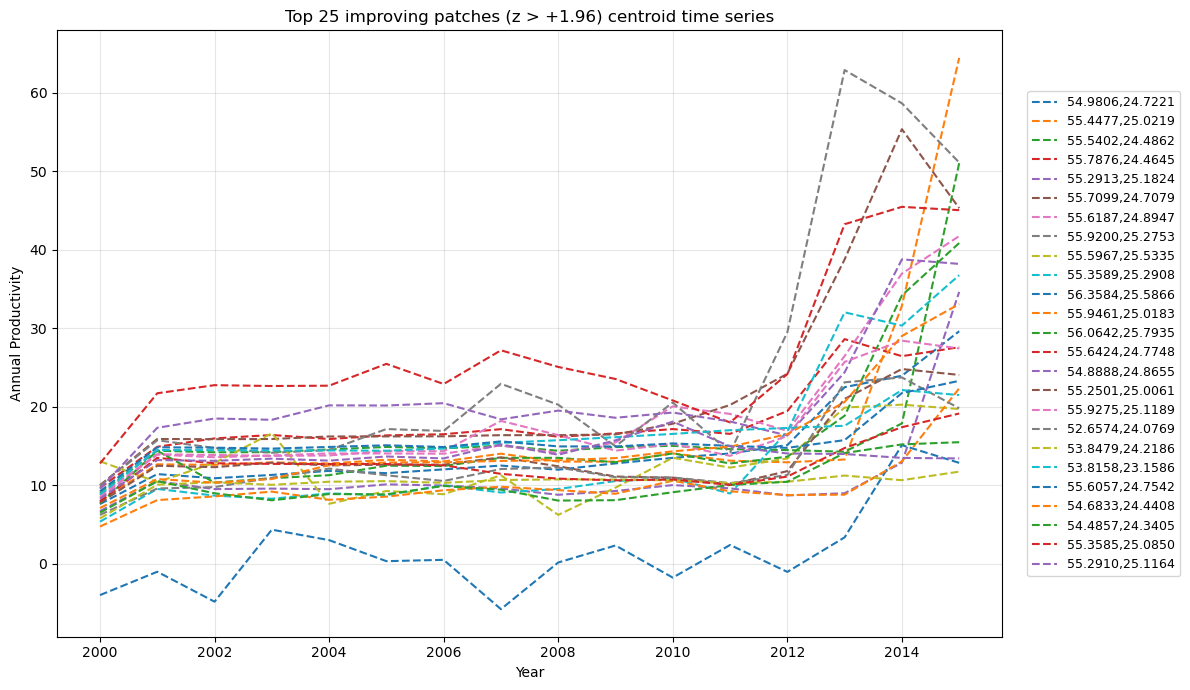

In [5]:
years = list(range(2000, 2016))

# Figure 12: degrading（z < -1.96）
df_deg, fig_deg, ax_deg, patches_deg = plot_topk_trend_patch_centroid_timeseries(
    annual_stack_tif="../data/NPP_PROXY/annual_auc_toBands_2000_2015.tif",
    trend_z_tif="../output/state/2015/zscore.tif",
    years=years,
    mode="degrading",
    topk=25,
    z_threshold=-1.96,
)

# Figure 13: improving（z > +1.96）
df_imp, fig_imp, ax_imp, patches_imp = plot_topk_trend_patch_centroid_timeseries(
    annual_stack_tif="../data/NPP_PROXY/annual_auc_toBands_2000_2015.tif",
    trend_z_tif="../output/state/2015/zscore.tif",
    years=years,
    mode="improving",
    topk=25,
    z_threshold=1.96,
)


In [ ]:
fig_deg.savefig("../output/trend/2015/degrading_pic.png")

fig_imp.savefig("../output/trend/2015/improving_pic.png")